# STAT 207 Homework 5 [25 points]

## Inference Procedures

Due: Monday, March 2, end of day (11:59 pm CT)

Late submissions accepted until Tuesday, March 3 at noon

<hr>

## Imports 

Run the following code cell to import the necessary packages into the file.  You may import additional packages, as needed for this assignment.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()
import statsmodels.formula.api as smf

## Case Study: Illinois Prison Terms

The state of Illinois Department of Corrections maintains and publishes data associated with the population of individuals that are currently in custody.  One of the datasets that they publish describes those who have exited prison or are projected to exit prison shortly for any number of reasons (https://idoc.illinois.gov/reportsandstatistics/prison-exit-data-sets.html).  This data was originally downloaded on 9/25/2025 and represents those who exited prison during the Fiscal Year 2025 (7/1/24 - 6/30/25).

We will use this data to represent our population of interest: all people who are sentenced to drug-related crimes in Illinois.  A portion of the variables from the data is saved as **IL-prison.csv** and located in the same folder as this homework file.

We will focus on a few variables in particular:

- the offense type variable (`Offense Type`)
- the number of years on the sentence (`Sentence Years`)
- the number of months on the sentence (`Sentence Months`)

Our goal: we'd like to make statements about how long the sentence for a person convicted of a crime is when at least one of the crimes is a drug-related offense for all people convicted of drug-related offenses in Illinois.

Note that there is considerable cleaning that could be performed with this data, as there is structure contained in the data.  For example, when the same person is found guilty of 2 or more crimes, there are multiple rows present in the data to represent each of these crimes.  For the purposes of this analysis, we will use the data as it currently stands without any modifications or filtering needed other than what is explicitly specified below.

## 1. Read and prepare the data [1.5 points] 

**a)** You should read in the data from the `IL-prison.csv` file.  This corresponds to a random sample of the available Illinois prison exits data.

In [6]:
df = pd.read_csv('IL-prison.csv')
df.head()

,Sentencing County,Offense Type,Sentence Years,Sentence Months
0,Henry,Drug Crimes,0001,006
1,McLean,Person Crimes,0005,000
2,Winnebago,Person Crimes,0002,000
3,Cook,Person Crimes,0004,000
4,Iroquois,Sex Crimes,0004,000


**b)** We are interested in making statements about the sentence length for those who have drug-related offenses.  First, let's reduce our data so that it only represents those rows that are reported as "Drug Crimes".

*Hint: You should have 153 observations left in your data.*

In [8]:
df_drug = df[df['Offense Type'] == 'Drug Crimes']
df_drug.head()

,Sentencing County,Offense Type,Sentence Years,Sentence Months
0,Henry,Drug Crimes,0001,006
9,Tazewell,Drug Crimes,0003,000
10,Cumberland,Drug Crimes,0007,006
11,Greene,Drug Crimes,0005,000
17,Winnebago,Drug Crimes,0006,000


**c)** Our variable of interest is the sentencing length for those who are convicted of drug crimes.  This variable is stored in two different variables in the data.  We need to clean and prepare this variable for analysis.

First, check the data types for the two sentencing length variables.  If needed, adjust the variable type so that they are recognized by Python as numbers.

In [10]:
df.dtypes

Sentencing County    object
Offense Type         object
Sentence Years       object
Sentence Months      object
dtype: object

In [15]:
df_drug[['Sentence Years', 'Sentence Months']] = df_drug[['Sentence Years', 'Sentence Months']].astype(float)


/var/folders/2b/x97clv852fg7sddsh44dvxhh0000gn/T/ipykernel_14717/592256191.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_drug[['Sentence Years', 'Sentence Months']] = df_drug[['Sentence Years', 'Sentence Months']].astype(float)


In [16]:
df_drug.dtypes

Sentencing County     object
Offense Type          object
Sentence Years       float64
Sentence Months      float64
dtype: object

**d)** Then, we would like to have a single variable `Sentence Length` that summarizes the sentence length contained in our two variables.  Calculate the `Sentence Length` variable in years by adding the current `Sentence Years` variable and an adjusted `Sentence Months` variable (divided by 12 to represent the length in years).  

*Hint: the first observation in the data for this variable should be 1.5 years.*

In [17]:
df_drug['Sentence Length'] = df_drug['Sentence Years'] + df_drug['Sentence Months'] / 12
df_drug.head()

/var/folders/2b/x97clv852fg7sddsh44dvxhh0000gn/T/ipykernel_14717/1528806012.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_drug['Sentence Length'] = df_drug['Sentence Years'] + df_drug['Sentence Months'] / 12


,Sentencing County,Offense Type,Sentence Years,Sentence Months,Sentence Length
0,Henry,Drug Crimes,1.0,6.0,1.5
9,Tazewell,Drug Crimes,3.0,0.0,3.0
10,Cumberland,Drug Crimes,7.0,6.0,7.5
11,Greene,Drug Crimes,5.0,0.0,5.0
17,Winnebago,Drug Crimes,6.0,0.0,6.0


**e)** Extra Gradescope Calculations

I'd suggest turning to Q1 on Gradescope here.

I don't anticipate a need to perform any more calculations or analyses for this problem.  This space is available for any optional calculations or analyses that you'd like.

## 2. Typical drug-related sentencing? [1.5 points]

Through an online search, it looks like a commonly suggested sentencing length from drug-related crimes is 5 years.  (Note: there are many nuances associated with the specific sentencing on a specific case, so this is a generalization).

We'd like to test if the mean sentence length for all sentences in Illinois that are associated with drug crimes is more lenient than is published, so we'd like to see if the mean sentence length is less than 5 years.  

We'd like to perform a hypothesis test using a 10% significance level based on our sample of sentences for drug crimes.

**a)** I'd suggest turning to Q2.1 & Q2.2 on Gradescope here.  After completing these two parts, I'd then return to parts **b** and **c** below.

**b)** Update our data to reflect the null hypothesis.

In [18]:
df_drug['Sentence Length Null'] = df_drug['Sentence Length'] - df_drug['Sentence Length'].mean() + 5
df_drug.head()

/var/folders/2b/x97clv852fg7sddsh44dvxhh0000gn/T/ipykernel_14717/1468080636.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_drug['Sentence Length Null'] = df_drug['Sentence Length'] - df_drug['Sentence Length'].mean() + 5


,Sentencing County,Offense Type,Sentence Years,Sentence Months,Sentence Length,Sentence Length Null
0,Henry,Drug Crimes,1.0,6.0,1.5,1.958606
9,Tazewell,Drug Crimes,3.0,0.0,3.0,3.458606
10,Cumberland,Drug Crimes,7.0,6.0,7.5,7.958606
11,Greene,Drug Crimes,5.0,0.0,5.0,5.458606
17,Winnebago,Drug Crimes,6.0,0.0,6.0,6.458606


In [19]:
df_drug.shape

(153, 6)

**c)** We will use our simulation-based procedures that we have developed so far this semester.

While we only have our one sample available, we will use it as a stand in for the population.  From our sample, gather a random sample with replacement of the same size as our original sample data.  We will then repeat this process to generate many random samples.  For each of our random samples, calculate and record our statistic of interest.  We will repeat this process 5000 times, and use the 5000 observations of our statistic of interest as a sampling distribution.

In [29]:
null = []
for i in range(5000):
    df_sample = df_drug.sample(153, replace=True)
    data = {'Null': df_sample['Sentence Length Null'].mean()}
    null.append(data)
df_null = pd.DataFrame(null, columns=['Null'])
df_null.head()

,Null
0,5.089325
1,4.934641
2,4.733115
3,4.948802
4,4.875272


**d)** Extra Gradescope Calculations

I'd suggest turning to the remainder of Q2 on Gradescope here.

You'll likely need to further explore the data for Gradescope Q2.  You can use this section for any exploration that you'd like, although there are no points associated with this part.

In [30]:
df_null.agg(['mean', 'std', 'min', 'max', 'count', 'quantile'])

,Null
mean,4.999164
std,0.250273
min,4.168845
max,5.995098
count,5000.000000
quantile,4.991013


array([[<Axes: title={'center': 'Null'}>]], dtype=object)

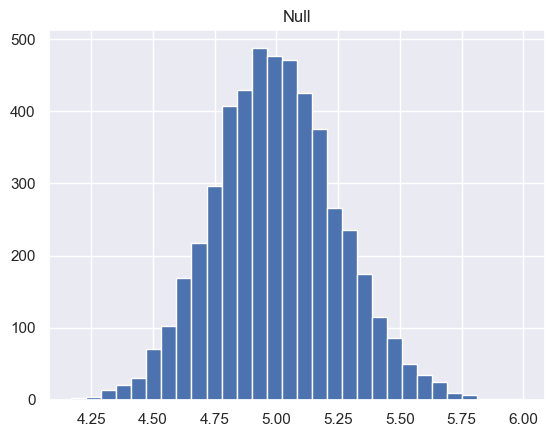

In [33]:
df_null.hist(bins=30)

In [35]:
mean = df_drug['Sentence Length'].mean()
p_value = (df_null['Null'] <= mean).mean()
p_value

np.float64(0.0302)

In [40]:
df_drug['Sentencing County'].unique()

array(['Henry', 'Tazewell', 'Cumberland', 'Greene', 'Winnebago',
       'St. Clair', 'Stephenson', 'McDonough', 'McHenry', 'Cook',
       'Marion', 'Sangamon', 'Union', 'Ford', 'Henderson', 'Madison',
       'Champaign', 'Jefferson', 'Will', 'Rock Island', 'Livingston',
       'Dupage', 'Grundy', 'Peoria', 'Kendall', 'Kane', 'Montgomery',
       'Macon', 'Fayette', 'Franklin', 'Shelby', 'Scott', 'Randolph',
       'Lasalle', 'Clay', 'Lake', 'Hardin', 'Monroe', 'Adams',
       'Christian', 'Whiteside', 'Jackson', 'Pike', 'Crawford', 'Fulton',
       'Morgan', 'McLean', 'Cass', 'Williamson', 'Woodford', 'Vermilion',
       'Coles', 'Hamilton', 'Kankakee', 'Perry', 'Wabash', 'Macoupin',
       'White'], dtype=object)

In [ ]:
df_drug_champaign = df_drug[df_drug['Sentencing County'] == 'Champaign'] 
df_drug_champaign.head

np.int64(3)

## Case Study: Kitchen Prep Time

The `food_prep.csv` file contains information about how much time a sample of American adults spent preparing food and drink (in minutes) in the last 24 hours.  The data has already been cleaned, so you don't need to worry about cleaning the data before analyzing it.

## 3. A Confidence Interval [1 point]

**a)** Read in the `food_prep.csv` file.  Then, generate a sampling distribution for the **median** time spent preparing food and drink by American adults.  Finally, find the 95% confidence interval using your sampling distribution.

In [64]:
df_food = pd.read_csv('food_prep.csv')
df_food.agg(['mean', 'median','std', 'min', 'max', 'count'])

,food_prep
mean,31.420000
median,15.000000
std,44.583324
min,0.000000
max,320.000000
count,400.000000


In [71]:
median = []
for i in range(5000):
    df_sample = df_food.sample(len(df_food), replace=True)
    data = {'Median': df_sample['food_prep'].median()}
    median.append(data)
df_median = pd.DataFrame(median, columns=['Median'])
df_median.head()

,Median
0,15.0
1,15.0
2,10.0
3,10.0
4,12.5


In [73]:
lower = df_median['Median'].quantile(0.025)
upper = df_median['Median'].quantile(0.975)
print(lower, upper)

10.0 20.0


**b)** Extra Gradescope Calculations

I'd suggest turning to Q3 on Gradescope here.

You'll likely need to further explore the data for Gradescope Q3.  You can use this section for any exploration that you'd like, although there are no points associated with this part.

array([[<Axes: title={'center': 'Median'}>]], dtype=object)

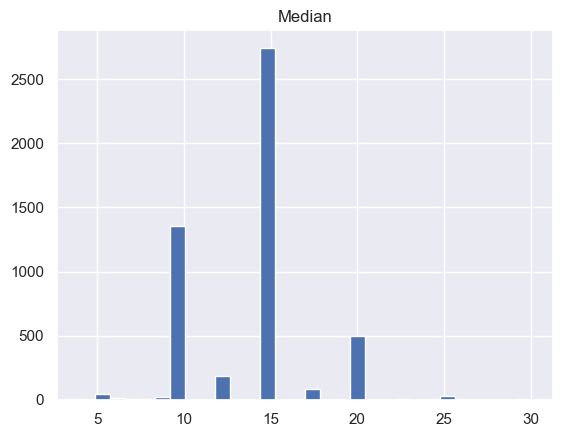

In [74]:
df_median.hist(bins=30)

In [75]:
df_median.agg(['mean', 'std', 'min', 'max', 'count', 'quantile'])

,Median
mean,14.014500
std,3.322009
min,4.000000
max,30.000000
count,5000.000000
quantile,15.000000


## 4. AI Acknowledgement

Our course policy is that you should write all of your own interpretations and other narrative answers (phrases or sentences) yourself without the assistance of AI.  You may use AI to help guide your code, although you should write all of your own code yourself (not copy-paste from another source) and you should cite your use of AI.  I would encourage you to try to generate any necessary code yourself first using course resources and using AI as a debugging tool if/when you reach an error that you can't figure out or to help you perform any coding tasks that are more advanced than we've demonstrated during class (intended only for projects).  

Did you use AI on this assignment?  Did you use other resources outside of our course-provided resources on this assignment?

No i did not

If you used AI or other resources, answer the following questions to cite your usage.

- Which AI and/or resources did you use (including links, if appropriate)?
- What prompts did you ask it?
- How did you integrate the responses into your assignment?  Specifically, which questions or parts are associated with this usage?

Note: answering these three questions are enough for our course but may not be enough for a different course or context.

N/A

Remember to keep all your cells and hit the save icon above periodically to checkpoint (save) your results on your local computer. Once you are satisified with your results restart the kernel and run all (Kernel -> Restart & Run All). **Make sure nothing has changed**. Checkpoint and exit (File -> Save and Checkpoint + File -> Close and Halt). Follow the instructions on the Homework 5 Canvas Assignment to submit your notebook to GitHub.